In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/Fall 2025/Responsible AI/RAI Project/Project Implementation"

df = pd.read_csv(base_path + '/nc_voted_with_predicted_party.csv')

# Using thresholding to assign race values for each row.

If the maximum probability out of prob_asian, prob_white, prob_hisp and prob_black is greater then 0.5 assign the corresponding race.

In [ ]:
import numpy as np

prob_cols_list = ['prob_white', 'prob_black', 'prob_asian', 'prob_hisp']
q = 0.5

prob_to_race_map = {
    'prob_white': 'W',
    'prob_black': 'B',
    'prob_asian': 'A',
    'prob_hisp': 'HL'
}

df['max_prob'] = df[prob_cols_list].max(axis=1)
df['max_prob_col'] = df[prob_cols_list].idxmax(axis=1)

df['predicted_race'] = np.where(
    df['max_prob'] > q,
    df['max_prob_col'].map(prob_to_race_map),
    'U'
)

df.drop(columns=['max_prob', 'max_prob_col'], inplace=True)

print("New 'predicted_race' column created based on maximum probability and 0.5 threshold.")

/tmp/ipython-input-2014763858.py:15: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df['max_prob_col'] = df[prob_cols_list].idxmax(axis=1)


New 'predicted_race' column created based on maximum probability and 0.5 threshold.


In [ ]:
races_to_keep = ['W', 'A', 'B', 'HL']
df.loc[~df['race_code'].isin(races_to_keep), 'race_code'] = 'U'

In [ ]:
print(q)

# Get value counts for predicted_race and race_code
predicted_race_counts = df['predicted_race'].value_counts().reindex(['W', 'B', 'A', 'HL', 'U'], fill_value=0)
race_code_counts = df['race_code'].value_counts().reindex(['W', 'B', 'A', 'HL', 'U'], fill_value=0)

# Create a DataFrame from the counts
comparison_df = pd.DataFrame({
    'predicted_race_count': predicted_race_counts,
    'race_code_count': race_code_counts
})

# Calculate the percentage difference
comparison_df['percentage_diff'] = ((comparison_df['predicted_race_count'] - comparison_df['race_code_count']) / comparison_df['race_code_count']) * 100

print("\nComparison of Predicted Race and True Race Counts:")
print(comparison_df.round(2))

0.5

Comparison of Predicted Race and True Race Counts:
    predicted_race_count  race_code_count  percentage_diff
W                 490305           465265             5.38
B                 138874           147863            -6.08
A                  12181            13443            -9.39
HL                 32245             5855           450.73
U                  86588           127767           -32.23


In [ ]:
print("Counts for predicted_race column:")
display(df['predicted_race'].value_counts().reindex(['W', 'B', 'A', 'HL', 'U']))

Counts for predicted_race column:


,count
predicted_race,
W,490305
B,138874
A,12181
HL,32245
U,86588


In [ ]:
print("\nCounts for race_code column:")
display(df['race_code'].value_counts().reindex(['W', 'B', 'A', 'HL', 'U']))


Counts for race_code column:


,count
race_code,
W,461808
B,147337
A,13373
HL,5812
U,65443


#Race Disparity

Race Disparity in the predicted parties calculated using the true race labels compared against race labels obtained using thresholding of BIFSG probabilities and against weighing.

In [ ]:
#RACE DISPARITY USING WEIGHING

In [ ]:
def true_disparity(df, race_col='race_code', target_party=None, reference='W'):
    results = {}
    # Calculate the proportion of target_party for the reference group
    ref_proportion = (df.loc[df[race_col] == reference, 'pred_party'] == target_party).mean()

    for g in df[race_col].unique():
        group_proportion = (df.loc[df[race_col] == g, 'pred_party'] == target_party).mean()
        results[g] = group_proportion - ref_proportion

    return pd.DataFrame({f'True Disparity ({target_party} vs {reference})': results})

In [ ]:
def thresholded_disparity(df, target_party=None, reference='W'):
    results = {}
    print(len(df))
    assigned = df.copy()
    print(len(assigned))
    # Calculate the proportion of target_party for the reference group in assigned (predicted_race)
    ref_proportion = (assigned.loc[assigned['predicted_race'] == reference, 'pred_party'] == target_party).mean()

    for g in assigned['predicted_race'].unique():
        group_proportion = (assigned.loc[assigned['predicted_race'] == g, 'pred_party'] == target_party).mean()
        results[g] = group_proportion - ref_proportion

    return pd.DataFrame({f'Thresholded Disparity ({target_party} vs {reference})': results})

In [ ]:
def weighted_bisg_disparity(df, prob_cols, outcome_col=None, reference='white'):
    results = {}
    # reference mean
    ref_weights = df[prob_cols[reference]]
    ref_mu = (ref_weights * df[outcome_col]).sum() / ref_weights.sum()

    for g, col in prob_cols.items():
        weights = df[col]
        mu_g = (weights * df[outcome_col]).sum() / weights.sum()
        results[g] = mu_g - ref_mu

    return pd.DataFrame({'Weighted Disparity': results})


In [ ]:
# Mapping race names to column names
prob_cols = {
    'white': 'prob_white',
    'black': 'prob_black',
    'asian': 'prob_asian',
    'hisp':  'prob_hisp'
}

parties = ['DEM', 'REP', 'UNA']
reference_race_code = 'W'
reference_predicted_race = 'W'
reference_prob_col = 'white'

print("TRUE DISPARITY")
for party in parties:
    true_disp = true_disparity(df, race_col='race_code', target_party=party, reference=reference_race_code)
    print(true_disp)

print("THRESHOLDED BISG DISPARITY")
for party in parties:
    thresh_disp = thresholded_disparity(df, target_party=party, reference=reference_predicted_race)
    print(thresh_disp)

print("\nWEIGHTED BISG DISPARITY")
for party in parties:
    temp_df = df.copy()
    temp_df[f'is_{party.lower()}'] = (temp_df['pred_party'] == party).astype(int)
    weighted_disp = weighted_bisg_disparity(temp_df, prob_cols, outcome_col=f'is_{party.lower()}', reference=reference_prob_col)
    print(weighted_disp.rename(columns={'Weighted Disparity': f'Weighted Disparity ({party} vs {reference_prob_col})'}))

### 1. TRUE DISPARITY ###
    True Disparity (DEM vs W)
U                   -0.052725
W                    0.000000
B                    0.347632
A                    0.055470
HL                   0.093243
    True Disparity (REP vs W)
U                   -0.214217
W                    0.000000
B                   -0.262393
A                   -0.217936
HL                  -0.214722
    True Disparity (UNA vs W)
U                    0.084237
W                    0.000000
B                   -0.081366
A                    0.164689
HL                   0.121565

### 2. THRESHOLDED BISG DISPARITY ###
760193
760193
    Thresholded Disparity (DEM vs W)
U                           0.115946
W                           0.000000
B                           0.276092
A                           0.048407
HL                          0.049438
760193
760193
    Thresholded Disparity (REP vs W)
U                          -0.130345
W                           0.000000
B                          -0.2340

# Accuracy Differences

Find the disparity in accuracy for the prediction using true race labels and the labels assigned using BIFSG probabilities.

In [ ]:
import pandas as pd

def accuracy_by_true_race(df, races):
    results = {}
    for r in races:
        group = df[df["race_code"] == r]
        acc = (group["pred_party"] == group["party_cd"]).mean()
        results[r] = acc
    return pd.Series(results, name="Accuracy_TrueRace")

def acc_by_race_party_true(df, races=["W","B","HL","A"], parties=["DEM","REP","UNA"]):
    rows = []
    for r in races:
        for p in parties:
            subset = df[(df["race_code"] == r) & (df["party_cd"] == p)]
            if len(subset) == 0:
                acc = None
            else:
                acc = (subset["pred_party"] == subset["party_cd"]).mean()
            rows.append([r, p, acc])
    return pd.DataFrame(rows, columns=["Race", "Party", "Acc_TrueRace"])




In [ ]:
def accuracy_by_bisg_thresh(df, races):
    results = {}
    for r in races:
        group = df[df["predicted_race"] == r]
        acc = (group["pred_party"] == group["party_cd"]).mean()
        results[r] = acc
    return pd.Series(results, name="Accuracy_BISG_Threshold")

def acc_by_race_party_thresh(df, races=["W","B","HL","A"], parties=["DEM","REP","UNA"]):
    rows = []
    for r in races:
        for p in parties:
            subset = df[(df["predicted_race"] == r) & (df["party_cd"] == p)]
            if len(subset) == 0:
                acc = None
            else:
                acc = (subset["pred_party"] == subset["party_cd"]).mean()
            rows.append([r, p, acc])
    return pd.DataFrame(rows, columns=["Race", "Party", "Acc_BISG_Threshold"])




In [ ]:
def accuracy_weighted_bisg(df, races, prob_cols):
    results = {}

    correct = (df["pred_party"] == df["party_cd"]).astype(int)

    for r in races:
        p = df[prob_cols[r]]
        weighted_correct = (p * correct).sum()
        weight_total = p.sum()
        acc = weighted_correct / weight_total if weight_total > 0 else None
        results[r] = acc

    return pd.Series(results, name="Accuracy_WeightedBISG")

prob_map = {
    "W": "prob_white",
    "B": "prob_black",
    "HL": "prob_hisp",
    "A": "prob_asian"
}

def acc_by_race_party_weighted(df, races=["W","B","HL","A"], parties=["DEM","REP","UNA"]):
    rows = []
    correct = (df["pred_party"] == df["party_cd"]).astype(int)

    for r in races:
        w = df[prob_map[r]]  # weights for race r

        for p in parties:
            mask = (df["party_cd"] == p)

            w_sub = w[mask]
            cw = (correct[mask] * w_sub)

            if w_sub.sum() == 0:
                acc = None
            else:
                acc = cw.sum() / w_sub.sum()

            rows.append([r, p, acc])

    return pd.DataFrame(rows, columns=["Race", "Party", "Acc_Weighted"])


In [ ]:
df_true = acc_by_race_party_true(df)
df_thresh = acc_by_race_party_thresh(df)
df_weight = acc_by_race_party_weighted(df)

final = df_true.merge(df_thresh, on=["Race", "Party"]).merge(df_weight, on=["Race", "Party"])

print(final)

   Race Party  Acc_TrueRace  Acc_BISG_Threshold  Acc_Weighted
0     W   DEM      0.729911            0.717298      0.720490
1     W   REP      0.729064            0.727152      0.727532
2     W   UNA      0.761407            0.766563      0.767505
3     B   DEM      0.739608            0.748481      0.743090
4     B   REP      0.579733            0.663017      0.687631
5     B   UNA      0.731750            0.767773      0.764878
6    HL   DEM      0.642601            0.636599      0.647332
7    HL   REP      0.614267            0.643516      0.653098
8    HL   UNA      0.786195            0.797737      0.794479
9     A   DEM      0.630597            0.624099      0.632218
10    A   REP      0.545646            0.541879      0.559118
11    A   UNA      0.782993            0.793578      0.791053


    Accuracy_TrueRace  Accuracy_BISG_Threshold  Accuracy_WeightedBISG
W            0.736428                 0.712811               0.713432
B            0.730129                 0.712005               0.709982
A            0.694413                 0.697890               0.697679
HL           0.703501                 0.690929               0.692305


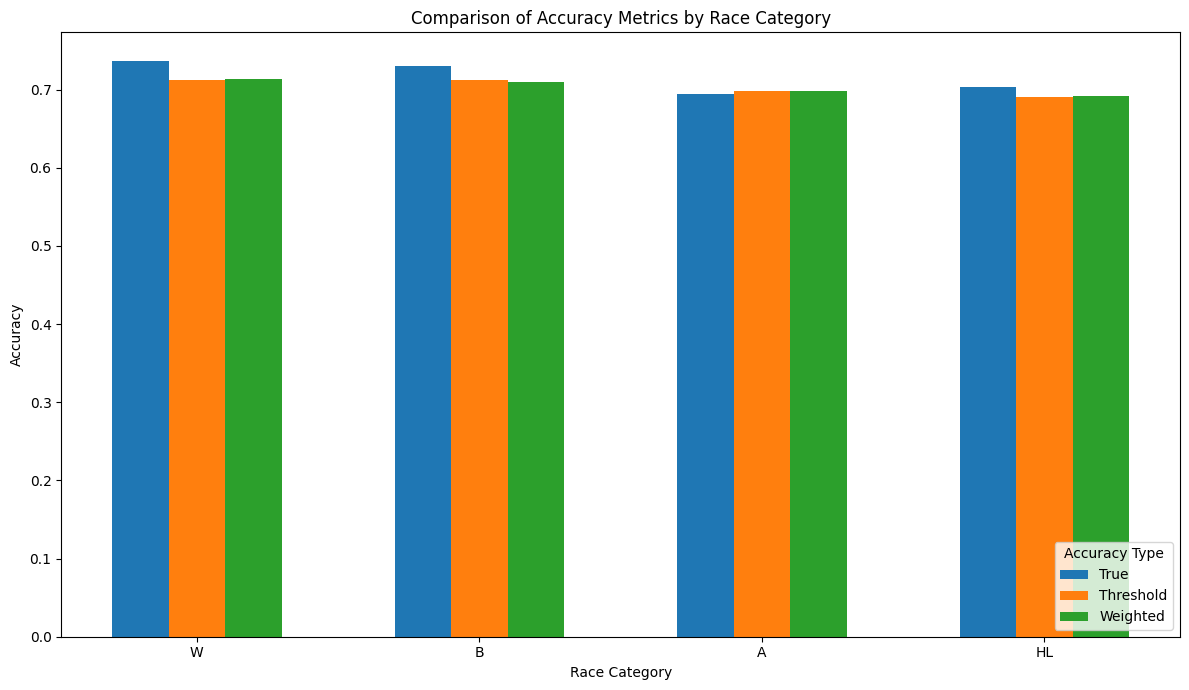

In [ ]:
races = ["W", "B", "A", "HL"]
prob_cols = {
    "W": "prob_white",
    "B": "prob_black",
    "A": "prob_asian",
    "HL": "prob_hisp"
}

acc_true = accuracy_by_true_race(df, races)
acc_thresh = accuracy_by_bisg_thresh(df, races)
acc_weighted = accuracy_weighted_bisg(df, races, prob_cols)

final = pd.concat([acc_true, acc_thresh, acc_weighted], axis=1)
print(final)

import matplotlib.pyplot as plt
# import pandas as pd # pandas is already imported

races = final.index

bar_width = 0.2
index = range(len(races))

fig, ax = plt.subplots(figsize=(12, 7))

bar1 = ax.bar([i - bar_width for i in index], final['Accuracy_TrueRace'], bar_width, label='True')
bar2 = ax.bar(index, final['Accuracy_BISG_Threshold'], bar_width, label='Threshold')
bar3 = ax.bar([i + bar_width for i in index], final['Accuracy_WeightedBISG'], bar_width, label='Weighted')

ax.set_xlabel('Race Category')
ax.set_ylabel('Accuracy')
ax.set_title('Comparison of Accuracy Metrics by Race Category')
ax.set_xticks(index)
ax.set_xticklabels(races)
ax.legend(title='Accuracy Type', loc='lower right')

plt.tight_layout()
plt.show()